<a href="https://colab.research.google.com/github/eugenb0t/polygon/blob/main/eai_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

Чтение датасета

In [ ]:
import numpy as np

def load_csv_with_numpy(filename, delimiter=',', skiprows=0, dtype=float):
    try:
        # Открываем файл для чтения
        with open(filename, 'r') as f:
            # Пропускаем указанное количество строк
            for _ in range(skiprows):
                next(f)

            # Читаем данные из оставшихся строк
            data = []
            for line in f:
                # Удаляем лишние пробелы и разделяем строку на значения
                values = line.strip().split(delimiter)
                # Преобразуем значения в указанный тип данных и добавляем в список
                data.append([dtype(v) for v in values])

        # Преобразуем список списков в массив NumPy
        return np.array(data)

    except Exception as e:
        print(f"Ошибка при загрузке файла: {e}")
        return None

filename = 'SeoulBikeData_1.csv'
data = load_csv_with_numpy(filename, skiprows=1, dtype=str)

if data is not None:
    print("Данные успешно загружены.")
    print(data)
else:
    print("Не удалось загрузить данные.")


Данные успешно загружены.
[['01/12/2017' '254' '0' ... 'Winter' 'No Holiday' 'Yes']
 ['01/12/2017' '204' '1' ... 'Winter' 'No Holiday' 'Yes']
 ['01/12/2017' '173' '2' ... 'Winter' 'No Holiday' 'Yes']
 ...
 ['30/11/2018' '694' '21' ... 'Autumn' 'No Holiday' 'Yes']
 ['30/11/2018' '712' '22' ... 'Autumn' 'No Holiday' 'Yes']
 ['30/11/2018' '584' '23' ... 'Autumn' 'No Holiday' 'Yes']]


In [ ]:
from datetime import datetime

Предобработка данных

In [ ]:
processed_data = []

for i in range(len(data)):
    processed_data.append([]) # Проходимся по всем строкам массива
    for j in range(len(data[i])):
        if j == 0:
            # Так как в первом столбце дата - прелбразуем ее в число
            date_object = datetime.strptime(data[i][j], '%d/%m/%Y')
            processed_data[i].append(date_object.timestamp() + float(data[i][j + 2]) * 3600) # Прибавляем часы из третьего столбца
            # Получаем количество секунд с 01.01.1970
        elif j in [2, 13]:
            # Скипаем 2 и 13 столбцы. Второй обработали выше, 13 - всегда "Yes"
            pass
        elif j == 11:
            # Преобразуем сезоны в числа
            if data[i][j] == "Winter":
                processed_data[i].append(0.0)
            if data[i][j] == "Spring":
                processed_data[i].append(1.0)
            if data[i][j] == "Summer":
                processed_data[i].append(2.0)
            if data[i][j] == "Autumn":
                processed_data[i].append(3.0)
        elif j == 12:
            # Преобразуем праздник/не праздник в 0/1
            if data[i][j] == "No Holiday":
                processed_data[i].append(0.0)
            if data[i][j] == "Holiday":
                processed_data[i].append(1.0)
        else:
            # Остальные столбцы уже содержат числа, так что просто преобразуем их в float
            processed_data[i].append(float(data[i][j]))

print(processed_data)
new_data = np.array(processed_data) # Создаем np.array из преобразованного массива
print(new_data)


[[1512086400.0, 254.0, -5.2, 37.0, 2.2, 2000.0, -17.6, 0.0, 0.0, 0.0, 0.0, 0.0], [1512090000.0, 204.0, -5.5, 38.0, 0.8, 2000.0, -17.6, 0.0, 0.0, 0.0, 0.0, 0.0], [1512093600.0, 173.0, -6.0, 39.0, 1.0, 2000.0, -17.7, 0.0, 0.0, 0.0, 0.0, 0.0], [1512097200.0, 107.0, -6.2, 40.0, 0.9, 2000.0, -17.6, 0.0, 0.0, 0.0, 0.0, 0.0], [1512100800.0, 78.0, -6.0, 36.0, 2.3, 2000.0, -18.6, 0.0, 0.0, 0.0, 0.0, 0.0], [1512104400.0, 100.0, -6.4, 37.0, 1.5, 2000.0, -18.7, 0.0, 0.0, 0.0, 0.0, 0.0], [1512108000.0, 181.0, -6.6, 35.0, 1.3, 2000.0, -19.5, 0.0, 0.0, 0.0, 0.0, 0.0], [1512111600.0, 460.0, -7.4, 38.0, 0.9, 2000.0, -19.3, 0.0, 0.0, 0.0, 0.0, 0.0], [1512115200.0, 930.0, -7.6, 37.0, 1.1, 2000.0, -19.8, 0.01, 0.0, 0.0, 0.0, 0.0], [1512118800.0, 490.0, -6.5, 27.0, 0.5, 1928.0, -22.4, 0.23, 0.0, 0.0, 0.0, 0.0], [1512122400.0, 339.0, -3.5, 24.0, 1.2, 1996.0, -21.2, 0.65, 0.0, 0.0, 0.0, 0.0], [1512126000.0, 360.0, -0.5, 21.0, 1.3, 1936.0, -20.2, 0.94, 0.0, 0.0, 0.0, 0.0], [1512129600.0, 449.0, 1.7, 23.0, 1.4

In [ ]:
# Преобразуем признаки из датасета в отдельные векторы

# Создаем списки под каждый фактор
rented_bike_count = []
temperature = []
wind_speed = []

# Раскидываем нужные значения по спискам
for i in range(len(new_data)):
    for j in range(len(new_data[i])):
        if j == 1:
             rented_bike_count.append(new_data[i][j])
        if j == 2:
             temperature.append(new_data[i][j])
        if j == 4:
             wind_speed.append(new_data[i][j])

# Преобразуем в np.array
rented_bike_count = np.array(rented_bike_count)
temperature = np.array(temperature)
wind_speed = np.array(wind_speed)

print(rented_bike_count)
print(temperature)
print(wind_speed)


[254. 204. 173. ... 694. 712. 584.]
[-5.2 -5.5 -6.  ...  2.6  2.1  1.9]
[2.2 0.8 1.  ... 0.3 1.  1.3]


In [ ]:
# Разбиваем на подмассивы по сезонам

# Вычисляем начало каждого сезона
winter_beginning = datetime.strptime("01/12/2017", '%d/%m/%Y').timestamp()
spring_beginning = datetime.strptime("01/03/2018", '%d/%m/%Y').timestamp()
summer_beginning = datetime.strptime("01/06/2018", '%d/%m/%Y').timestamp()
autumn_beginning = datetime.strptime("01/09/2018", '%d/%m/%Y').timestamp()

# Заводим подмассивы
winter_data = []
spring_data = []
summer_data = []
autumn_data = []

# Распределяем все данные по сезонам
for vec in new_data:
    if winter_beginning <= vec[0] < spring_beginning:
        winter_data.append(vec)
    elif spring_beginning <= vec[0] < summer_beginning:
        spring_data.append(vec)
    elif summer_beginning <= vec[0] < autumn_beginning:
        summer_data.append(vec)
    else:
        autumn_data.append(vec)

# Преобразуем в np.array
winter_data = np.array(winter_data)
spring_data = np.array(spring_data)
summer_data = np.array(summer_data)
autumn_data = np.array(autumn_data)

print(winter_data)
print(spring_data)
print(summer_data)
print(autumn_data)


[[ 1.5120864e+09  2.5400000e+02 -5.2000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5120900e+09  2.0400000e+02 -5.5000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5120936e+09  1.7300000e+02 -6.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 1.5198516e+09  1.0000000e+01  2.4000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5198552e+09  1.3000000e+01  2.3000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5198588e+09  2.3000000e+01  1.8000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]]
[[1.5198624e+09 7.1000000e+01 2.0000000e+00 ... 0.0000000e+00
  1.0000000e+00 1.0000000e+00]
 [1.5198660e+09 1.4700000e+02 2.1000000e+00 ... 0.0000000e+00
  1.0000000e+00 1.0000000e+00]
 [1.5198696e+09 1.8000000e+02 2.0000000e+00 ... 0.0000000e+00
  1.0000000e+00 1.0000000e+00]
 ...
 [1.5278004e+09 2.0700000e+03 2.1900000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [1.5278040e+09 1.90000

In [ ]:
# Разбиваем на подмассивы по критерию празник/не праздник

# Заводим помассивы на оба случая
holiday_data = []
no_holiday_data = []

# Проверяем каждый вектор по критерию
for vec in new_data:
    no_holiday_data.append(vec) if vec[11] == 0 else holiday_data.append(vec)

# Преобразуем в np.array
holiday_data = np.array(holiday_data)
no_holiday_data = np.array(no_holiday_data)

print(holiday_data)
print(no_holiday_data)


[[ 1.5139008e+09  1.9600000e+02 -1.7000000e+00 ...  8.0000000e-01
   0.0000000e+00  1.0000000e+00]
 [ 1.5139044e+09  2.5000000e+02 -1.6000000e+00 ...  8.0000000e-01
   0.0000000e+00  1.0000000e+00]
 [ 1.5139080e+09  1.6100000e+02 -1.1000000e+00 ...  8.0000000e-01
   0.0000000e+00  1.0000000e+00]
 ...
 [ 1.5391188e+09  0.0000000e+00  1.6800000e+01 ...  0.0000000e+00
   3.0000000e+00  1.0000000e+00]
 [ 1.5391224e+09  0.0000000e+00  1.6700000e+01 ...  0.0000000e+00
   3.0000000e+00  1.0000000e+00]
 [ 1.5391260e+09  0.0000000e+00  1.6600000e+01 ...  0.0000000e+00
   3.0000000e+00  1.0000000e+00]]
[[ 1.5120864e+09  2.5400000e+02 -5.2000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5120900e+09  2.0400000e+02 -5.5000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.5120936e+09  1.7300000e+02 -6.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 1.5436116e+09  6.9400000e+02  2.6000000e+00 ...  0.0000000e+00
   3.0000000e+00  0.0000000e+00]

In [ ]:
print(spring_data[0] + autumn_data[0]) # Сложение
print(spring_data[0] - winter_data[0]) # Вычитание
print(summer_data[0] * 4) # Умножение на скаляр

[3.0556224e+09 1.1460000e+03 2.5200000e+01 1.7900000e+02 1.8000000e+00
 3.7810000e+03 2.1500000e+01 0.0000000e+00 2.0000000e+00 0.0000000e+00
 4.0000000e+00 1.0000000e+00]
[ 7.776e+06 -1.830e+02  7.200e+00  5.900e+01 -9.000e-01 -1.060e+02
  1.900e+01  0.000e+00  2.000e+00  0.000e+00  1.000e+00  1.000e+00]
[6.1112448e+09 3.8520000e+03 8.0400000e+01 2.5200000e+02 4.4000000e+00
 6.7920000e+03 5.1200000e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00
 8.0000000e+00 0.0000000e+00]


In [ ]:
# Преобразуем вектор-строку в вектор-столбец
autumn_col_vec = []

for i in range(len(autumn_data[0])):
    autumn_col_vec.append([autumn_data[0][i]])

autumn_col_vec = np.array(autumn_col_vec)

print(autumn_col_vec)

[[1.53576e+09]
 [1.07500e+03]
 [2.32000e+01]
 [8.30000e+01]
 [5.00000e-01]
 [1.88700e+03]
 [2.01000e+01]
 [0.00000e+00]
 [0.00000e+00]
 [0.00000e+00]
 [3.00000e+00]
 [0.00000e+00]]


In [ ]:
print(autumn_col_vec + summer_data[0]) # broadcasting

[[3.06357120e+09 1.53576096e+09 1.53576002e+09 1.53576006e+09
  1.53576000e+09 1.53576170e+09 1.53576001e+09 1.53576000e+09
  1.53576000e+09 1.53576000e+09 1.53576000e+09 1.53576000e+09]
 [1.52781228e+09 2.03800000e+03 1.09510000e+03 1.13800000e+03
  1.07610000e+03 2.77300000e+03 1.08780000e+03 1.07500000e+03
  1.07500000e+03 1.07500000e+03 1.07700000e+03 1.07500000e+03]
 [1.52781122e+09 9.86200000e+02 4.33000000e+01 8.62000000e+01
  2.43000000e+01 1.72120000e+03 3.60000000e+01 2.32000000e+01
  2.32000000e+01 2.32000000e+01 2.52000000e+01 2.32000000e+01]
 [1.52781128e+09 1.04600000e+03 1.03100000e+02 1.46000000e+02
  8.41000000e+01 1.78100000e+03 9.58000000e+01 8.30000000e+01
  8.30000000e+01 8.30000000e+01 8.50000000e+01 8.30000000e+01]
 [1.52781120e+09 9.63500000e+02 2.06000000e+01 6.35000000e+01
  1.60000000e+00 1.69850000e+03 1.33000000e+01 5.00000000e-01
  5.00000000e-01 5.00000000e-01 2.50000000e+00 5.00000000e-01]
 [1.52781309e+09 2.85000000e+03 1.90710000e+03 1.95000000e+03
  1

In [ ]:
# Функция вычисление коэффицента корреляции Пирсона

def pirson_coeff_similarity(a, b):
    # Вычислем среднее арифметическое каждого вектора
    mean_a, mean_b = 0, 0

    for i in range(len(a)):
        mean_a += a[i]
        mean_b += b[i]

    mean_a, mean_b = mean_a / len(a), mean_b / len(b)

    # Вычисляем необходимые суммы
    numerator_sum = 0
    denominator_sum_a, denominator_sum_b = 0, 0

    for i in range(len(a)):
        numerator_sum += (a[i] - mean_a) * (b[i] - mean_b)
        denominator_sum_a += (a[i] - mean_a) ** 2
        denominator_sum_b += (b[i] - mean_b) ** 2

    # Вычисляем коэффицент
    r = numerator_sum / np.sqrt(denominator_sum_a * denominator_sum_b)

    return r

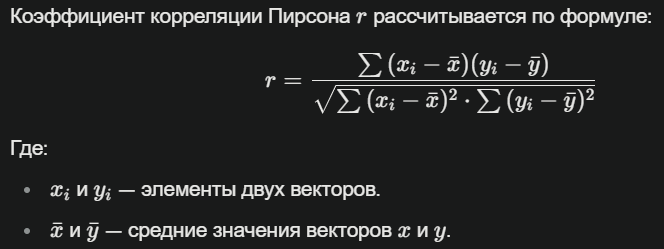

In [ ]:
# Корреляция между количеством арендованных велосипедов и температурой
print(pirson_coeff_similarity(rented_bike_count, temperature))

0.5385581530139745


In [ ]:
# Корреляция между количеством арендованных велосипедов и температурой
# Вычисленная при помощи встроенной функции numpy
print(np.corrcoef(rented_bike_count, temperature))

[[1.         0.53855815]
 [0.53855815 1.        ]]


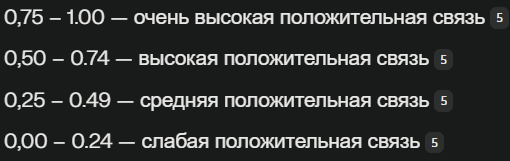

Можно оценивать связь как высокую положительную

Также можно увидеть, что результаты самописной и встроенной функции совпадают

In [ ]:
# Функция вычисления косинуса угла между векторами

def cosine_similarity(a, b):
    # Скалярное произведение кол-ва арендованных велосипедов и температуры
    ab_dot = np.dot(a, b)

    # Вычисление модулей векторов
    mod_a, mod_b = 0, 0

    for i in range(len(a)):
        mod_a += a[i] ** 2
        mod_b += b[i] ** 2

    mod_a, mod_b = np.sqrt(mod_a), np.sqrt(mod_b)

    # Вычисление косинуса между векторами
    cos_phi = ab_dot / (mod_a * mod_b)
    return cos_phi

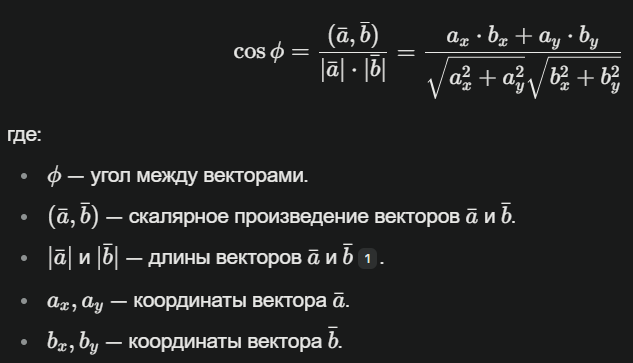

In [ ]:
# Корреляция между количеством арендованных велосипедов и температурой
print(cosine_similarity(rented_bike_count, temperature))

0.7881519894084649


In [ ]:
# Не нашел готовой фунции numpy для нахождения косинуса, использовал "композицию"

def np_cos_sim(a, b):
    return a.dot(b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [ ]:
print(np_cos_sim(rented_bike_count, temperature))

0.7881519894084646



Значение косинуса достаточно близко к 1, что соответствует острому углу

Это может говорить о наличии корреляции между выбранными величинами

Также результаты работы функций вновь совпадают

In [ ]:
# Функция нормализации векторов

def normalize_vector(vector):
    # Вычисляем длину (норму) вектора
    magnitude = np.sqrt(sum(x ** 2 for x in vector))

    # Нормализуем каждый элемент, деля его на длину вектора
    normalized_vector = [x / magnitude for x in vector]

    return normalized_vector

In [ ]:
# Нормализуем вектор температуры
norm_temp = normalize_vector(temperature)
print(norm_temp)

[-0.0031625007506528727, -0.003344952717036692, -0.003649039327676392, -0.0037706739719322716, -0.003649039327676392, -0.0038923086161881514, -0.004013943260444031, -0.00450048183746755, -0.004622116481723429, -0.003953125938316091, -0.002128606274477895, -0.0003040866106396993, 0.0010338944761749775, 0.0014596157310705566, 0.001824519663838196, 0.001277163764686737, 0.0007298078655352783, 0.00048653857702351893, 0.00036490393276763914, 0.0, -0.00018245196638381957, -0.00048653857702351893, -0.0005473558991514587, -0.0007906251876632182, -0.0010947117983029174, -0.001337981086814677, -0.0017637023417102558, -0.002128606274477895, -0.0023110582408617146, -0.0024326928851175944, -0.002615144851501414, -0.002675962173629354, -0.002554327529373474, -0.0017637023417102558, -0.00024326928851175946, 0.0011555291204308573, 0.002615144851501414, 0.003649039327676392, 0.00443966451533961, 0.004622116481723429, 0.0038923086161881514, 0.003649039327676392, 0.003344952717036692, 0.00304086610639699

In [ ]:
print(np.linalg.norm(norm_temp)) # Проверяем корректность нормализации

0.9999999999999999


In [ ]:
# Функция поиска схожего вектора по запросу

def find_similar_vector(vec_to_search, data):
    # Создаем словари под каждый критерий схожести
    pirson_sim = {}
    cosine_sim = {}

    # Нормализуем вектор для поиска
    normalized_v2s = vec_to_search / np.linalg.norm(vec_to_search)

    for i in range(len(data)):
        if vec_to_search[0] != data[i][0]: # Если вектор не буквально тот же
            # Нормализуем текущий вектор из данных
            tmp_vec_norm = data[i] / np.linalg.norm(data[i])
            # Добавляем в словари значение корреляции по ключу (индексу) вектора в исходном массиве
            pirson_sim[i] = np.corrcoef(normalized_v2s, tmp_vec_norm)[0][1]
            cosine_sim[i] = np_cos_sim(normalized_v2s, tmp_vec_norm)

    # Извлекаем индексы найденых векторов с наибольшими коэффицентами
    most_sim_pirson_index = max(pirson_sim, key=pirson_sim.get)
    most_sim_cosine_index = max(cosine_sim, key=cosine_sim.get)

    # Возвращаем пары значений вектор - коэффицент
    return (data[most_sim_pirson_index], pirson_sim[most_sim_pirson_index]), (data[most_sim_cosine_index], cosine_sim[most_sim_cosine_index])


In [ ]:
# Преобразуем желаемую дату (00:00:00 01.01.2018) в UNIX-формат
first_january = datetime.strptime("01/01/2018", '%d/%m/%Y').timestamp()

# Ищем соответстввующий вектор в датасете
for i in range(len(new_data)):
    if new_data[i][0] == first_january:
        first_jan_vector = vec
        break

# Записываем результат работы функции
result_tuple = find_similar_vector(first_jan_vector, new_data)

print("Target vector: ", first_jan_vector)
print("Most similar pirson vec: ", result_tuple[0][0], "\nCoeff of simmilarity: ", result_tuple[0][1])
print("Most similar cosine vec: ", result_tuple[1][0], "\nCoeff of simmilarity: ", result_tuple[1][1])


Target vector:  [ 1.5436188e+09  5.8400000e+02  1.9000000e+00  4.3000000e+01
  1.3000000e+00  1.9090000e+03 -9.3000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  3.0000000e+00  0.0000000e+00]
Most similar pirson vec:  [ 1.5175584e+09  5.5800000e+02 -7.4000000e+00  5.8000000e+01
  2.2000000e+00  1.8820000e+03 -1.4200000e+01  1.0000000e-02
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00] 
Coeff of simmilarity:  1.0
Most similar cosine vec:  [ 1.5175584e+09  5.5800000e+02 -7.4000000e+00  5.8000000e+01
  2.2000000e+00  1.8820000e+03 -1.4200000e+01  1.0000000e-02
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00] 
Coeff of simmilarity:  1.0


In [ ]:
print(datetime.fromtimestamp(result_tuple[0][0][0]))
print(datetime.fromtimestamp(result_tuple[1][0][0]))

2018-02-02 08:00:00
2018-02-02 08:00:00


Наиболее схожие "часы" с первым "часом" 2018

Как можно видеть, в данном случае найденные по обеим метрикам "часы" совпадают

In [ ]:
def time_series_filter(time_series, filter_kernel):
    # Длина временного ряда и ядра фильтра
    n = len(time_series)
    m = len(filter_kernel)

    # Создаем массив для хранения результата
    filtered_series = np.zeros(n - m + 1)

    # Применяем фильтр, вычисляя скалярное произведение для каждого участка
    for i in range(n - m + 1):
        # Извлекаем участок временного ряда, соответствующий размеру ядра
        window = time_series[i:i + m]

        # Вычисляем скалярное произведение участка и ядра фильтра
        filtered_series[i] = np.dot(window, filter_kernel)

    return filtered_series


In [ ]:
# Создаем список под значения времени
bike_time = []

for vec in new_data:
    bike_time.append(vec[0])

bike_time = np.array(bike_time)
filter = np.array([0.5, 0.5]) # Простое скользащее среднее

filtered_bike_time = time_series_filter(bike_time, filter) # Фильтруем
print(bike_time)
print(filtered_bike_time)


[1.5120864e+09 1.5120900e+09 1.5120936e+09 ... 1.5436116e+09 1.5436152e+09
 1.5436188e+09]
[1.5120882e+09 1.5120918e+09 1.5120954e+09 ... 1.5436098e+09 1.5436134e+09
 1.5436170e+09]


In [ ]:
for filtered_time in filtered_bike_time[:10]:
    print(datetime.fromtimestamp(filtered_time))
print()
for filtered_time in filtered_bike_time[-10:]:
    print(datetime.fromtimestamp(filtered_time))

2017-12-01 00:30:00
2017-12-01 01:30:00
2017-12-01 02:30:00
2017-12-01 03:30:00
2017-12-01 04:30:00
2017-12-01 05:30:00
2017-12-01 06:30:00
2017-12-01 07:30:00
2017-12-01 08:30:00
2017-12-01 09:30:00

2018-11-30 13:30:00
2018-11-30 14:30:00
2018-11-30 15:30:00
2018-11-30 16:30:00
2018-11-30 17:30:00
2018-11-30 18:30:00
2018-11-30 19:30:00
2018-11-30 20:30:00
2018-11-30 21:30:00
2018-11-30 22:30:00


In [ ]:
def kmeans_clustering(data, k, max_iters=100):
    # Инициализация центроидов случайным образом
    centroids = data[np.random.choice(data.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Для каждой точки находим ближайший центроид
        distances = np.sqrt(((data - centroids[:, np.newaxis]) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=0)

        # Вычисляем новые центроиды как средние значения точек в каждом кластере
        new_centroids = np.array([data[labels == i].mean(axis=0)
                                  for i in range(k)])

        # Если центроиды не изменились, заканчиваем
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return labels, centroids


In [ ]:
# Проверка для случая k = 2
labels, centroids =  kmeans_clustering(new_data, 2)
print(labels)
print(centroids)


[0 0 0 ... 1 1 1]
[[ 1.51996860e+09  4.81659132e+02  5.37995434e+00  5.43335616e+01
   1.89664384e+00  1.34185662e+03 -4.01173516e+00  4.96337900e-01
   1.08378995e-01  1.22054795e-01  5.09589041e-01  6.02739726e-02]
 [ 1.53573660e+09  9.27544977e+02  2.03858904e+01  6.21189498e+01
   1.55317352e+00  1.53179498e+03  1.21593607e+01  6.41883562e-01
   1.88995434e-01  2.80821918e-02  2.49863014e+00  3.83561644e-02]]


Похоже, что две сформированные группы соответствуют временным промежуткам по полгода

Проверим эту гипотезу

In [ ]:
first_zero = 0

# Ищем первый "0"
for i in range(1, len(labels)):
    if labels[i - 1] == 1 and labels[i] == 0:
        first_zero = i
        break

print(datetime.fromtimestamp(new_data[first_zero][0]))


2017-12-01 00:00:00


Гипотеза практически подтвердилась: дни разбились на кластеры декабрь-май и июнь-ноябрь

In [ ]:
# Попробуем поэкспериментировать со значением k

for k in range(3, 6):
    # Разбиваем на k кластеров
    labels, centroids =  kmeans_clustering(new_data, k)

    print(f"Для k = {k}")
    print(labels)
    print(centroids, end='\n\n')

    border_indices = []

    # Ищем границы
    for i in range(len(labels)):
        if labels[i - 1] != labels[i]:
            border_indices.append(i)

    # Выводим дату и время
    for i in border_indices:
        print(datetime.fromtimestamp(new_data[i][0]))

    print()


Для k = 3
[0 0 0 ... 1 1 1]
[[ 1.51734240e+09  3.00592605e+02  2.54022595e-01  5.22653201e+01
   1.91961657e+00  1.36602225e+03 -9.20585416e+00  3.75593975e-01
   4.19034577e-02  1.83019514e-01  2.60527217e-01  7.39472783e-02]
 [ 1.53836640e+09  8.34405276e+02  1.77998287e+01  6.06235012e+01
   1.54936622e+00  1.59847037e+03  9.33881466e+00  5.67149709e-01
   1.61253854e-01  4.21377184e-02  2.74820144e+00  4.93319630e-02]
 [ 1.52785620e+09  9.78991096e+02  2.06009247e+01  6.17928082e+01
   1.70561644e+00  1.34606438e+03  1.20948288e+01  7.64654110e-01
   2.42945205e-01  0.00000000e+00  1.50445205e+00  2.46575342e-02]]

2017-12-01 00:00:00
2018-04-01 17:00:00
2018-08-01 09:00:00

Для k = 4
[1 1 1 ... 3 3 3]
[[ 1.53178560e+09  1.03160064e+03  2.66152442e+01  6.49575536e+01
   1.61077134e+00  1.50119900e+03  1.87716568e+01  7.64153355e-01
   2.55454131e-01  0.00000000e+00  2.00000000e+00  2.19078047e-02]
 [ 1.51602300e+09  2.25175960e+02 -2.51211152e+00  4.99072212e+01
   1.94053931e+00  

Как можно заметить, данные разбиваются почти идеально на промежутки по 12 / k месяцев

Скорее всего, это связано с тем, что в соседние месяцы погодные и прочие условия наиболее схожи

In [ ]:
# Ищем допустимые пределы для генерации данных

borders = []

# Перебираем все параметры
for i in range(12):
    # Иницилизируем переменные для хранения мин и макс значений
    tmp_min, tmp_max = new_data[0][i], new_data[0][i]

    # Ищем мин и макс
    for j in range(len(new_data)):
        tmp_min = min(tmp_min, new_data[j][i])
        tmp_max = max(tmp_max, new_data[j][i])

    # Добавляем в список
    borders.append((tmp_min, tmp_max))

print(borders)


[(1512086400.0, 1543618800.0), (0.0, 3556.0), (-17.8, 39.4), (0.0, 98.0), (0.0, 7.4), (27.0, 2000.0), (-30.6, 27.2), (0.0, 3.52), (0.0, 35.0), (0.0, 8.8), (0.0, 3.0), (0.0, 1.0)]


In [ ]:
# Генерация случайного "часа"

gen_hour = []

for scale in borders:
    gen_hour.append(np.random.uniform(scale[0], scale[1]))

gen_hour = np.array(gen_hour)
print(gen_hour)


[ 1.53245065e+09  1.82838445e+03 -6.12789186e-01  3.87736479e+01
  4.61109717e+00  1.11139762e+03 -7.55277675e+00  1.35406701e+00
  1.70672995e+01  6.23096296e+00  2.36646809e+00  8.16524162e-01]


In [ ]:
# Ищем схожие векторы при помощи ранее написанной функции

result_tuple = find_similar_vector(gen_hour, new_data)

print("Target vector: ", gen_hour)
print("Most similar pirson vec: ", result_tuple[0][0], "\nCoeff of simmilarity: ", result_tuple[0][1])
print("Most similar cosine vec: ", result_tuple[1][0], "\nCoeff of simmilarity: ", result_tuple[1][1])

Target vector:  [ 1.53245065e+09  1.82838445e+03 -6.12789186e-01  3.87736479e+01
  4.61109717e+00  1.11139762e+03 -7.55277675e+00  1.35406701e+00
  1.70672995e+01  6.23096296e+00  2.36646809e+00  8.16524162e-01]
Most similar pirson vec:  [1.5262164e+09 1.8390000e+03 1.9100000e+01 6.5000000e+01 1.9000000e+00
 1.1450000e+03 1.2300000e+01 2.2600000e+00 0.0000000e+00 0.0000000e+00
 1.0000000e+00 0.0000000e+00] 
Coeff of simmilarity:  0.9999999999999992
Most similar cosine vec:  [1.5262164e+09 1.8390000e+03 1.9100000e+01 6.5000000e+01 1.9000000e+00
 1.1450000e+03 1.2300000e+01 2.2600000e+00 0.0000000e+00 0.0000000e+00
 1.0000000e+00 0.0000000e+00] 
Coeff of simmilarity:  0.9999999999999994


In [ ]:
# Часы, наиболее схожие со сгенерированным
print(datetime.fromtimestamp(gen_hour[0]))
print(datetime.fromtimestamp(result_tuple[0][0][0]))
print(datetime.fromtimestamp(result_tuple[1][0][0]))

2018-07-24 16:44:06.351657
2018-05-13 13:00:00
2018-05-13 13:00:00


За счет того, что мы задали рамки генерации, сгенерированные данные получились правдоподобными и похожими на исходные

In [ ]:
import matplotlib.pyplot as plt

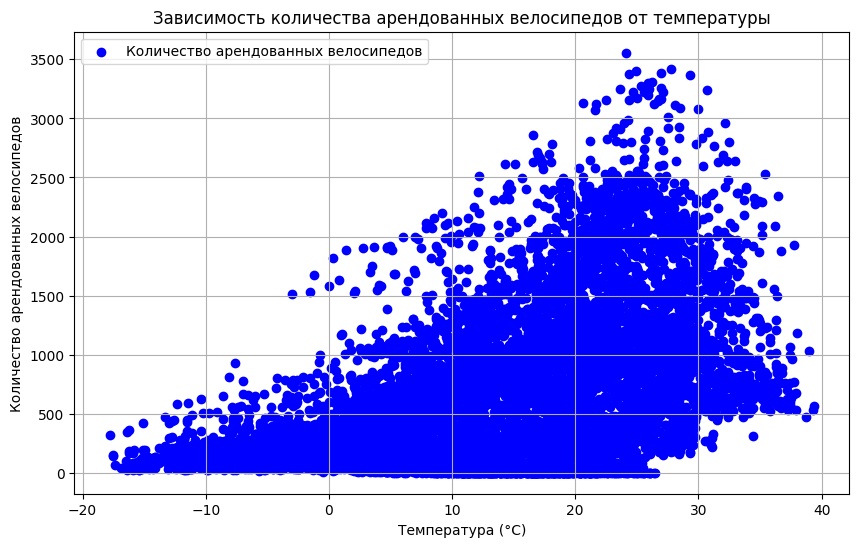

In [ ]:
# Выделяем данные о количестве велосипедов и температуре
rented_bikes = new_data[:, 1]
temperature = new_data[:, 2]

# Создаем график
plt.figure(figsize=(10, 6))
plt.scatter(temperature, rented_bikes, color='blue', label='Количество арендованных велосипедов')

# Добавляем заголовок и метки осей
plt.title('Зависимость количества арендованных велосипедов от температуры')
plt.xlabel('Температура (°C)')
plt.ylabel('Количество арендованных велосипедов')
plt.legend()

# Показываем график
plt.grid()
plt.show()

In [ ]:
import matplotlib.dates as mdates

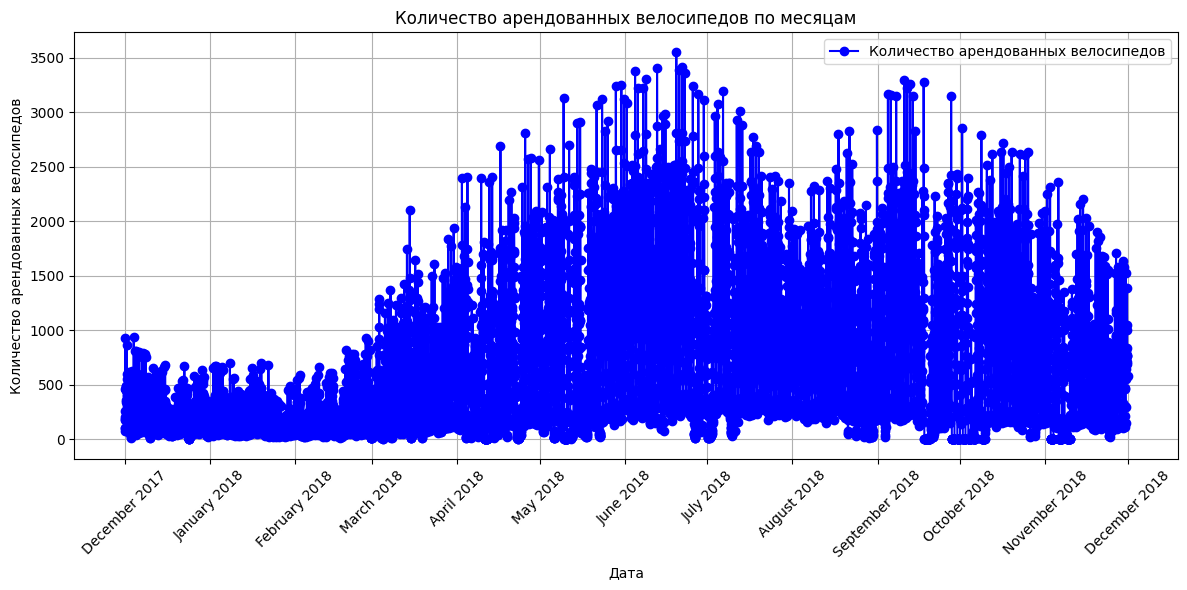

In [ ]:
# Извлекаем временные метки и количество арендованных велосипедов
timestamps = new_data[:, 0]  # Первый столбец: временные метки Unix
rented_bikes = new_data[:, 1] # Второй столбец: количество арендованных велосипедов

# Преобразуем временные метки Unix в читаемый формат
dates = [datetime.fromtimestamp(ts) for ts in timestamps]

# Создаем график
plt.figure(figsize=(12, 6))

# Используем plot для отображения данных
plt.plot(dates, rented_bikes, marker='o', linestyle='-', color='blue', label='Количество арендованных велосипедов')

# Форматируем ось X для отображения только месяцев
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Устанавливаем деления по месяцам
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))  # Форматируем отображение дат

# Добавляем заголовок и метки осей
plt.title('Количество арендованных велосипедов по месяцам')
plt.xlabel('Дата')
plt.ylabel('Количество арендованных велосипедов')
plt.xticks(rotation=45)  # Поворачиваем метки оси X для удобства чтения
plt.legend()
plt.grid()

# Показываем график
plt.tight_layout()  # Подгоняем элементы графика для лучшего отображения
plt.show()

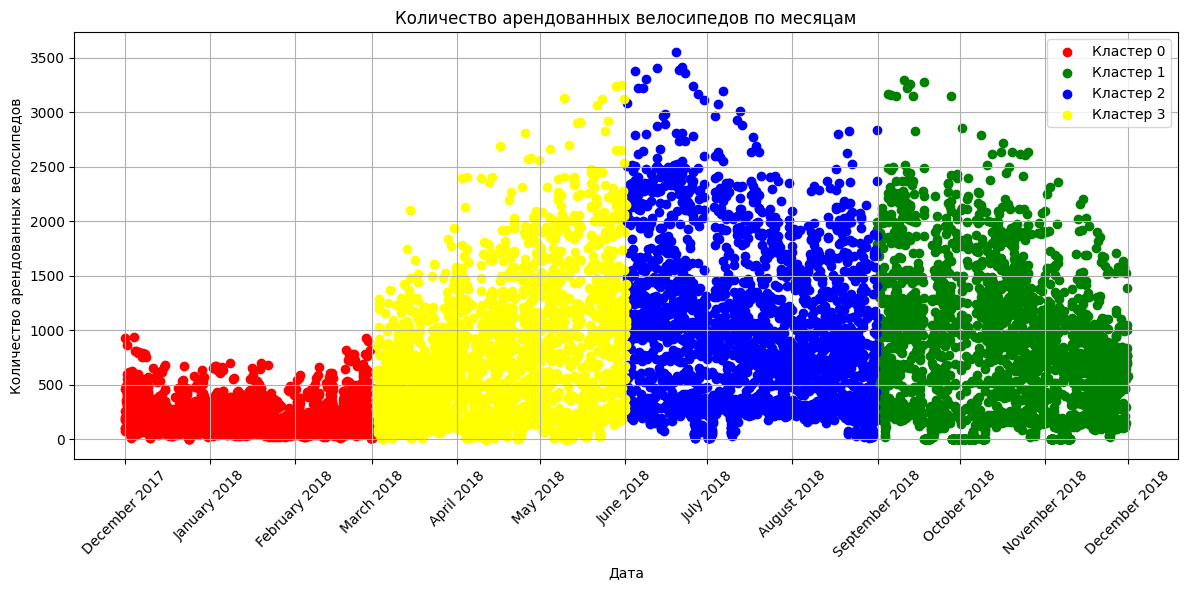

In [ ]:
# Отобразим кластеры, полученные по методу k средних
labels, centroids = kmeans_clustering(new_data, 4)

# Преобразуем временные метки Unix в читаемый формат
dates = [datetime.fromtimestamp(ts) for ts in new_data[:, 0]]

# Определяем цвета для каждого кластера
colors = ['red', 'green', 'blue', 'yellow']

# Создаем график
plt.figure(figsize=(12, 6))

# Проходим по каждому кластеру и отображаем его данные
for i in range(len(colors)):
    # Выбираем данные для текущего кластера
    cluster_data = new_data[labels == i]

    # Преобразуем временные метки для текущего кластера в даты
    cluster_dates = [datetime.fromtimestamp(ts) for ts in cluster_data[:, 0]]

    # Строим график для текущего кластера
    plt.scatter(cluster_dates, cluster_data[:, 1], color=colors[i], label=f'Кластер {i}')

# Форматируем ось X для отображения только месяцев
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())     # Устанавливаем деления по месяцам
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%B %Y')) # Форматируем отображение дат (месяц и год)

# Добавляем заголовок и метки осей
plt.title('Количество арендованных велосипедов по месяцам')
plt.xlabel('Дата')
plt.ylabel('Количество арендованных велосипедов')
plt.xticks(rotation=45)  # Поворачиваем метки оси X для удобства чтения
plt.legend()
plt.grid()

# Показываем график
plt.tight_layout()
plt.show()